# Weighted Motif Intensity & Sign-Coherence Features for Capability Clustering

This notebook demonstrates how **weighted motif features** (Onnela-style intensity, sign-coherence, path dominance, weight asymmetry) computed on 3-node DAG motifs in neural attribution graphs can cluster capability domains far better than binary motif counts alone.

**What this does:**
1. Loads pre-computed per-graph motif features from 200 Neuronpedia attribution graphs across 8 capability domains
2. Compares 5 feature sets (weighted motif, binary motif baseline, graph stats, weighted+binary, all combined) via spectral clustering NMI/ARI
3. Runs permutation tests, ANOVA discriminative analysis, weight-topology interactions, and sign-coherence patterns
4. Visualizes clustering quality and feature importance

In [1]:
import subprocess, sys
def _pip(*a): subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *a])

# Packages NOT pre-installed on Colab (always install everywhere)
_pip('python-igraph==0.11.8')
_pip('loguru==0.7.3')

# Core packages (pre-installed on Colab, install locally to match Colab env)
if 'google.colab' not in sys.modules:
    # scipy 1.16.3 requires Python >=3.11 (Colab); use 1.15.3 for Python 3.10
    _scipy = 'scipy==1.16.3' if sys.version_info >= (3, 11) else 'scipy==1.15.3'
    _pip('numpy==2.0.2', 'pandas==2.2.2', 'scikit-learn==1.6.1',
         _scipy, 'matplotlib==3.10.0', 'seaborn==0.13.2')


[notice] A new release of pip is available: 23.0.1 -> 26.0.1
[notice] To update, run: python3 -m pip install --upgrade pip



[notice] A new release of pip is available: 23.0.1 -> 26.0.1
[notice] To update, run: python3 -m pip install --upgrade pip



[notice] A new release of pip is available: 23.0.1 -> 26.0.1
[notice] To update, run: python3 -m pip install --upgrade pip


In [2]:
import json
import math
import os
import time
from collections import Counter, defaultdict

import numpy as np
import scipy.stats
from sklearn.cluster import SpectralClustering
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
GITHUB_DATA_URL = "https://raw.githubusercontent.com/ai-inventor-outputs/ai-invention-582cc7-circuit-motif-spectroscopy-discovering-u/main/experiment_iter4_weighted_motif/demo/mini_demo_data.json"

def load_data():
    try:
        import urllib.request
        with urllib.request.urlopen(GITHUB_DATA_URL) as response:
            return json.loads(response.read().decode())
    except Exception:
        pass
    if os.path.exists("mini_demo_data.json"):
        with open("mini_demo_data.json") as f:
            return json.load(f)
    raise FileNotFoundError("Could not load mini_demo_data.json")

In [4]:
data = load_data()
print(f"Loaded data with {len(data['datasets'][0]['examples'])} examples")
print(f"Metadata keys: {list(data['metadata'].keys())}")

Loaded data with 24 examples
Metadata keys: ['method_name', 'description', 'parameters', 'n_graphs_processed', 'n_domains', 'domain_counts', 'total_runtime_seconds', 'processing_time_seconds', 'clustering_comparison', 'permutation_tests', 'discriminative_features', 'weight_topology_interaction', 'sign_coherence_analysis', 'per_domain_aggregated', 'feature_set_definitions']


## Configuration

All tunable parameters for the analysis. Start with minimum values for fast execution.

In [5]:
# --- Config ---
SEED = 42
CLUSTER_K_VALUES = [2, 4, 6, 8]  # Original: [2, 4, 6, 8]
N_PERMUTATIONS = 50  # Original: 1000 — kept small for demo speed

np.random.seed(SEED)

## Phase A: Parse Pre-computed Per-Graph Features

Each example in the data contains pre-computed weighted motif features (FFL intensity, sign-coherence, path dominance, etc.) and binary motif ratios. We parse these into feature dictionaries.

In [6]:
examples = data["datasets"][0]["examples"]

per_graph_features = []
domains = []

for ex in examples:
    output = json.loads(ex["output"])
    feats = output["per_graph_features"]
    binary = output["binary_motif_ratios"]
    # Merge binary ratios into feature dict
    feats.update(binary)
    per_graph_features.append(feats)
    domains.append(ex["metadata_fold"])

n_processed = len(per_graph_features)
domain_counts = Counter(domains)
print(f"Parsed {n_processed} graphs across {len(domain_counts)} domains")
print(f"Domain distribution: {dict(domain_counts)}")

Parsed 24 graphs across 8 domains
Domain distribution: {'antonym': 3, 'arithmetic': 3, 'code_completion': 3, 'country_capital': 3, 'multi_hop_reasoning': 3, 'rhyme': 3, 'sentiment': 3, 'translation': 3}


## Phase B: Define Feature Sets

We compare 5 feature sets to see which best clusters capability domains:
- **weighted_motif_only**: Onnela intensity, sign-coherence, path dominance, weight asymmetry (19 features)
- **binary_motif_only**: Simple triad census ratios (4 features)
- **graph_stats_only**: Basic graph statistics (8 features)
- **weighted_plus_binary**: Weighted + binary combined (23 features)
- **all_combined**: Everything together (31 features)

In [7]:
FEATURE_SETS = {
    "weighted_motif_only": [
        "ffl_intensity_mean", "ffl_intensity_median", "ffl_intensity_std",
        "ffl_intensity_q25", "ffl_intensity_q75",
        "ffl_coherent_frac", "ffl_path_dom_mean", "ffl_path_dom_std",
        "ffl_asymmetry_mean", "ffl_coherence_onnela_mean", "ffl_coherence_onnela_std",
        "chain_intensity_mean", "chain_sign_agree_frac",
        "fanout_intensity_mean", "fanout_sign_agree_frac",
        "fanin_intensity_mean", "fanin_sign_agree_frac",
        "neg_edge_frac", "edge_weight_kurtosis",
    ],
    "binary_motif_only": [
        "ratio_030T", "ratio_021D", "ratio_021U", "ratio_021C",
    ],
    "graph_stats_only": [
        "n_nodes", "n_edges", "density", "mean_degree",
        "max_degree", "diameter_approx", "n_layers", "edge_weight_mean",
    ],
    "weighted_plus_binary": [
        "ffl_intensity_mean", "ffl_intensity_median", "ffl_intensity_std",
        "ffl_intensity_q25", "ffl_intensity_q75",
        "ffl_coherent_frac", "ffl_path_dom_mean", "ffl_path_dom_std",
        "ffl_asymmetry_mean", "ffl_coherence_onnela_mean", "ffl_coherence_onnela_std",
        "chain_intensity_mean", "chain_sign_agree_frac",
        "fanout_intensity_mean", "fanout_sign_agree_frac",
        "fanin_intensity_mean", "fanin_sign_agree_frac",
        "neg_edge_frac", "edge_weight_kurtosis",
        "ratio_030T", "ratio_021D", "ratio_021U", "ratio_021C",
    ],
    "all_combined": [
        "ffl_intensity_mean", "ffl_intensity_median", "ffl_intensity_std",
        "ffl_intensity_q25", "ffl_intensity_q75",
        "ffl_coherent_frac", "ffl_path_dom_mean", "ffl_path_dom_std",
        "ffl_asymmetry_mean", "ffl_coherence_onnela_mean", "ffl_coherence_onnela_std",
        "chain_intensity_mean", "chain_sign_agree_frac",
        "fanout_intensity_mean", "fanout_sign_agree_frac",
        "fanin_intensity_mean", "fanin_sign_agree_frac",
        "neg_edge_frac", "edge_weight_kurtosis",
        "ratio_030T", "ratio_021D", "ratio_021U", "ratio_021C",
        "n_nodes", "n_edges", "density", "mean_degree",
        "max_degree", "diameter_approx", "n_layers", "edge_weight_mean",
    ],
}

print(f"Feature sets defined: {list(FEATURE_SETS.keys())}")
for name, cols in FEATURE_SETS.items():
    print(f"  {name}: {len(cols)} features")

Feature sets defined: ['weighted_motif_only', 'binary_motif_only', 'graph_stats_only', 'weighted_plus_binary', 'all_combined']
  weighted_motif_only: 19 features
  binary_motif_only: 4 features
  graph_stats_only: 8 features
  weighted_plus_binary: 23 features
  all_combined: 31 features


## Phase C: Clustering Comparison (Spectral Clustering NMI/ARI)

For each feature set, we run spectral clustering at different K values and measure agreement with the true capability domain labels via Normalized Mutual Information (NMI) and Adjusted Rand Index (ARI).

In [8]:
def run_clustering_comparison(feature_matrix, labels, feature_set_name, k_values):
    """Run spectral clustering for each K, compute NMI/ARI."""
    scaler = StandardScaler()
    X = scaler.fit_transform(feature_matrix)

    results = {}
    predictions = {}
    for K in k_values:
        try:
            sc = SpectralClustering(
                n_clusters=K, affinity="rbf", random_state=SEED, n_init=10
            )
            pred = sc.fit_predict(X)
            nmi = float(normalized_mutual_info_score(labels, pred))
            ari = float(adjusted_rand_score(labels, pred))
            results[str(K)] = {"nmi": nmi, "ari": ari}
            predictions[str(K)] = pred.tolist()
        except Exception as e:
            print(f"Clustering failed for {feature_set_name} K={K}: {e}")
            results[str(K)] = {"nmi": 0.0, "ari": 0.0}
            predictions[str(K)] = [0] * len(labels)

    best_k = max(results, key=lambda k: results[k]["nmi"])
    return {
        "results_by_k": results,
        "best_k": int(best_k),
        "best_nmi": results[best_k]["nmi"],
        "best_ari": results[best_k]["ari"],
        "n_features": int(feature_matrix.shape[1]),
        "n_graphs": int(feature_matrix.shape[0]),
        "best_k_predictions": predictions[best_k],
    }


labels_arr = np.array(domains)
clustering_results = {}

for fs_name, fs_cols in FEATURE_SETS.items():
    X = np.array([[fd.get(c, 0.0) for c in fs_cols] for fd in per_graph_features])
    X = np.nan_to_num(X, nan=0.0, posinf=100.0, neginf=-100.0)
    result = run_clustering_comparison(X, labels_arr, fs_name, CLUSTER_K_VALUES)
    clustering_results[fs_name] = result
    print(f"  {fs_name}: best_k={result['best_k']}, "
          f"NMI={result['best_nmi']:.4f}, ARI={result['best_ari']:.4f}")

  weighted_motif_only: best_k=6, NMI=0.7771, ARI=0.4697
  binary_motif_only: best_k=8, NMI=0.5293, ARI=0.0424
  graph_stats_only: best_k=6, NMI=0.6778, ARI=0.2494
  weighted_plus_binary: best_k=6, NMI=0.7771, ARI=0.4697
  all_combined: best_k=6, NMI=0.7577, ARI=0.4170


## Phase D: Permutation Tests for NMI Differences

We test whether the NMI advantage of weighted features over binary features is statistically significant by shuffling domain labels and recomputing the NMI difference.

In [9]:
def cluster_and_nmi(X, labels, K):
    """Run spectral clustering and return NMI."""
    try:
        sc = SpectralClustering(
            n_clusters=K, affinity="rbf", random_state=SEED, n_init=10
        )
        pred = sc.fit_predict(X)
        return float(normalized_mutual_info_score(labels, pred))
    except Exception:
        return 0.0


def permutation_test_nmi(X1, X2, labels, n_perms=50, K=8):
    """Test if NMI(X1) > NMI(X2) is significant by shuffling labels."""
    scaler1 = StandardScaler()
    scaler2 = StandardScaler()
    X1s = scaler1.fit_transform(X1)
    X2s = scaler2.fit_transform(X2)

    nmi1_real = cluster_and_nmi(X1s, labels, K)
    nmi2_real = cluster_and_nmi(X2s, labels, K)
    observed_diff = nmi1_real - nmi2_real

    rng = np.random.RandomState(SEED)
    count_exceed = 0
    for _ in range(n_perms):
        shuffled = rng.permutation(labels)
        nmi1_perm = cluster_and_nmi(X1s, shuffled, K)
        nmi2_perm = cluster_and_nmi(X2s, shuffled, K)
        if (nmi1_perm - nmi2_perm) >= observed_diff:
            count_exceed += 1

    p_value = (count_exceed + 1) / (n_perms + 1)
    return {
        "nmi_X1": nmi1_real,
        "nmi_X2": nmi2_real,
        "observed_diff": observed_diff,
        "p_value": p_value,
        "n_permutations": n_perms,
    }


# Use best K from weighted_motif_only
best_overall_k = clustering_results.get("weighted_motif_only", {}).get("best_k", 8)

perm_results = {}
comparisons = [
    ("weighted_vs_binary", "weighted_motif_only", "binary_motif_only"),
    ("weighted_vs_graph_stats", "weighted_motif_only", "graph_stats_only"),
    ("combined_vs_best_single", "all_combined", "weighted_motif_only"),
    ("weighted_plus_binary_vs_binary", "weighted_plus_binary", "binary_motif_only"),
]

for comp_name, fs1_name, fs2_name in comparisons:
    fs1_cols = FEATURE_SETS[fs1_name]
    fs2_cols = FEATURE_SETS[fs2_name]
    X1 = np.array([[fd.get(c, 0.0) for c in fs1_cols] for fd in per_graph_features])
    X2 = np.array([[fd.get(c, 0.0) for c in fs2_cols] for fd in per_graph_features])
    X1 = np.nan_to_num(X1, nan=0.0, posinf=100.0, neginf=-100.0)
    X2 = np.nan_to_num(X2, nan=0.0, posinf=100.0, neginf=-100.0)

    result = permutation_test_nmi(X1, X2, labels_arr, n_perms=N_PERMUTATIONS, K=best_overall_k)
    perm_results[comp_name] = result
    print(f"  {comp_name}: diff={result['observed_diff']:.4f}, p={result['p_value']:.4f}")

  weighted_vs_binary: diff=0.3220, p=0.0196


  weighted_vs_graph_stats: diff=0.0993, p=0.1373


  combined_vs_best_single: diff=-0.0194, p=0.6667


  weighted_plus_binary_vs_binary: diff=0.3220, p=0.0196


## Phase E: Discriminative Feature Analysis (ANOVA eta-squared)

Which individual features best separate capability domains? We run one-way ANOVA per feature and compute eta-squared effect sizes.

In [10]:
def discriminative_analysis(feature_dict_list, labels, feature_names):
    """ANOVA F-test per feature; eta-squared effect size."""
    unique_domains = sorted(set(labels))
    labels_arr = np.array(labels)
    results = {}

    for feat_name in feature_names:
        try:
            vals = np.array([fd[feat_name] for fd in feature_dict_list], dtype=float)
        except (KeyError, TypeError):
            continue

        groups = [vals[labels_arr == d] for d in unique_domains]
        groups = [g for g in groups if len(g) >= 2]
        if len(groups) < 2:
            continue

        try:
            f_stat, p_val = scipy.stats.f_oneway(*groups)
        except Exception:
            continue

        if np.isnan(f_stat):
            continue

        grand_mean = np.mean(vals)
        ss_between = sum(len(g_arr) * (np.mean(g_arr) - grand_mean) ** 2 for g_arr in groups)
        ss_total = np.sum((vals - grand_mean) ** 2)
        eta_sq = ss_between / ss_total if ss_total > 0 else 0.0

        per_domain = {d: float(np.mean(vals[labels_arr == d]))
                      for d in unique_domains if np.sum(labels_arr == d) > 0}

        results[feat_name] = {
            "F_statistic": float(f_stat),
            "p_value": float(p_val),
            "eta_squared": float(eta_sq),
            "per_domain_means": per_domain,
        }

    ranked = sorted(results.items(), key=lambda x: x[1]["eta_squared"], reverse=True)
    return {"all_features": results, "top_5": dict(ranked[:5])}


all_feature_names = FEATURE_SETS["all_combined"]
disc_results = discriminative_analysis(per_graph_features, domains, all_feature_names)

print("Top 5 most discriminative features (by eta-squared):")
for fname, fdata in disc_results["top_5"].items():
    print(f"  {fname}: eta^2={fdata['eta_squared']:.4f}, "
          f"F={fdata['F_statistic']:.2f}, p={fdata['p_value']:.2e}")

Top 5 most discriminative features (by eta-squared):
  n_nodes: eta^2=0.9615, F=57.14, p=3.90e-10
  ffl_path_dom_mean: eta^2=0.9463, F=40.27, p=5.44e-09
  max_degree: eta^2=0.9328, F=31.71, p=3.18e-08
  ffl_path_dom_std: eta^2=0.9227, F=27.29, p=9.45e-08
  density: eta^2=0.9008, F=20.77, p=6.59e-07


/ai-inventor/aii_pipeline/runs/neuronpedia-circuit-interpretability/4_gen_paper_repo/notebook_workspaces/exp_id1_it4__opus/.nb_env/lib/python3.10/site-packages/scipy/stats/_axis_nan_policy.py:586: ConstantInputWarning: Each of the input arrays is constant; the F statistic is not defined or infinite
  res = hypotest_fun_out(*samples, **kwds)


## Phase F: Weight-Topology Interaction & Sign Coherence

We analyze the correlation between FFL count (topology) and mean FFL intensity (weight) per domain, and examine sign-coherence patterns across domains.

In [11]:
def weight_topology_interaction(per_graph_features, domain_labels):
    """Correlation between FFL count and mean FFL intensity per domain."""
    results = {}
    for domain in sorted(set(domain_labels)):
        mask = [i for i, d in enumerate(domain_labels) if d == domain]
        counts = [per_graph_features[i]["ffl_count"] for i in mask]
        intensities = [per_graph_features[i]["ffl_intensity_mean"] for i in mask]

        if len(counts) >= 3:
            try:
                r, p = scipy.stats.pearsonr(counts, intensities)
                results[domain] = {
                    "pearson_r": float(r),
                    "p_value": float(p),
                    "n": len(counts),
                    "interpretation": (
                        "complementary" if abs(r) < 0.3
                        else "correlated" if r > 0
                        else "anticorrelated"
                    ),
                }
            except Exception:
                results[domain] = {"pearson_r": 0.0, "p_value": 1.0, "n": len(counts),
                                   "interpretation": "insufficient_data"}

    all_counts = [f["ffl_count"] for f in per_graph_features]
    all_intensities = [f["ffl_intensity_mean"] for f in per_graph_features]
    try:
        r_all, p_all = scipy.stats.pearsonr(all_counts, all_intensities)
        results["overall"] = {"pearson_r": float(r_all), "p_value": float(p_all)}
    except Exception:
        results["overall"] = {"pearson_r": 0.0, "p_value": 1.0}

    return results


def sign_coherence_analysis(per_graph_features, domain_labels):
    """Aggregate sign coherence patterns per domain."""
    results = {}
    for domain in sorted(set(domain_labels)):
        mask = [i for i, d in enumerate(domain_labels) if d == domain]
        coherent_fracs = [per_graph_features[i]["ffl_coherent_frac"] for i in mask]
        ffl_counts = [per_graph_features[i]["ffl_count"] for i in mask]

        merged_patterns = Counter()
        for i in mask:
            for pat, cnt in per_graph_features[i].get("sign_pattern_counts", {}).items():
                merged_patterns[pat] += cnt

        total_patterns = sum(merged_patterns.values())
        pattern_dist = {k: v / max(total_patterns, 1) for k, v in merged_patterns.most_common(8)}

        results[domain] = {
            "coherent_frac_mean": float(np.mean(coherent_fracs)) if coherent_fracs else 0.0,
            "coherent_frac_std": float(np.std(coherent_fracs)) if coherent_fracs else 0.0,
            "sign_pattern_distribution": pattern_dist,
            "n_ffls_total": int(sum(ffl_counts)),
            "n_graphs": len(mask),
        }
    return results


# Weight-topology interaction
wt_interaction = weight_topology_interaction(per_graph_features, domains)
if "overall" in wt_interaction:
    print(f"Overall count-intensity correlation: "
          f"r={wt_interaction['overall']['pearson_r']:.4f}, "
          f"p={wt_interaction['overall']['p_value']:.4f}")
for domain, res in sorted(wt_interaction.items()):
    if domain != "overall" and "pearson_r" in res:
        print(f"  {domain}: r={res['pearson_r']:.3f} ({res.get('interpretation', '')})")

# Sign coherence analysis
print("\nSign coherence per domain:")
sign_coh = sign_coherence_analysis(per_graph_features, domains)
for domain, sdata in sorted(sign_coh.items()):
    print(f"  {domain}: coherent_frac={sdata['coherent_frac_mean']:.4f}, "
          f"n_ffls={sdata['n_ffls_total']}")

Overall count-intensity correlation: r=-0.8820, p=0.0000
  antonym: r=-0.974 (anticorrelated)
  arithmetic: r=-0.854 (anticorrelated)
  code_completion: r=-0.936 (anticorrelated)
  country_capital: r=-0.967 (anticorrelated)
  multi_hop_reasoning: r=-0.824 (anticorrelated)
  rhyme: r=-0.983 (anticorrelated)
  sentiment: r=-0.996 (anticorrelated)
  translation: r=-0.828 (anticorrelated)

Sign coherence per domain:
  antonym: coherent_frac=0.5910, n_ffls=53463
  arithmetic: coherent_frac=0.5524, n_ffls=102239
  code_completion: coherent_frac=0.5851, n_ffls=145536
  country_capital: coherent_frac=0.5811, n_ffls=153570
  multi_hop_reasoning: coherent_frac=0.5744, n_ffls=77449
  rhyme: coherent_frac=0.5891, n_ffls=217868
  sentiment: coherent_frac=0.5792, n_ffls=456070
  translation: coherent_frac=0.6035, n_ffls=180036


## Results Visualization

Compare clustering quality across feature sets and visualize the most discriminative features.

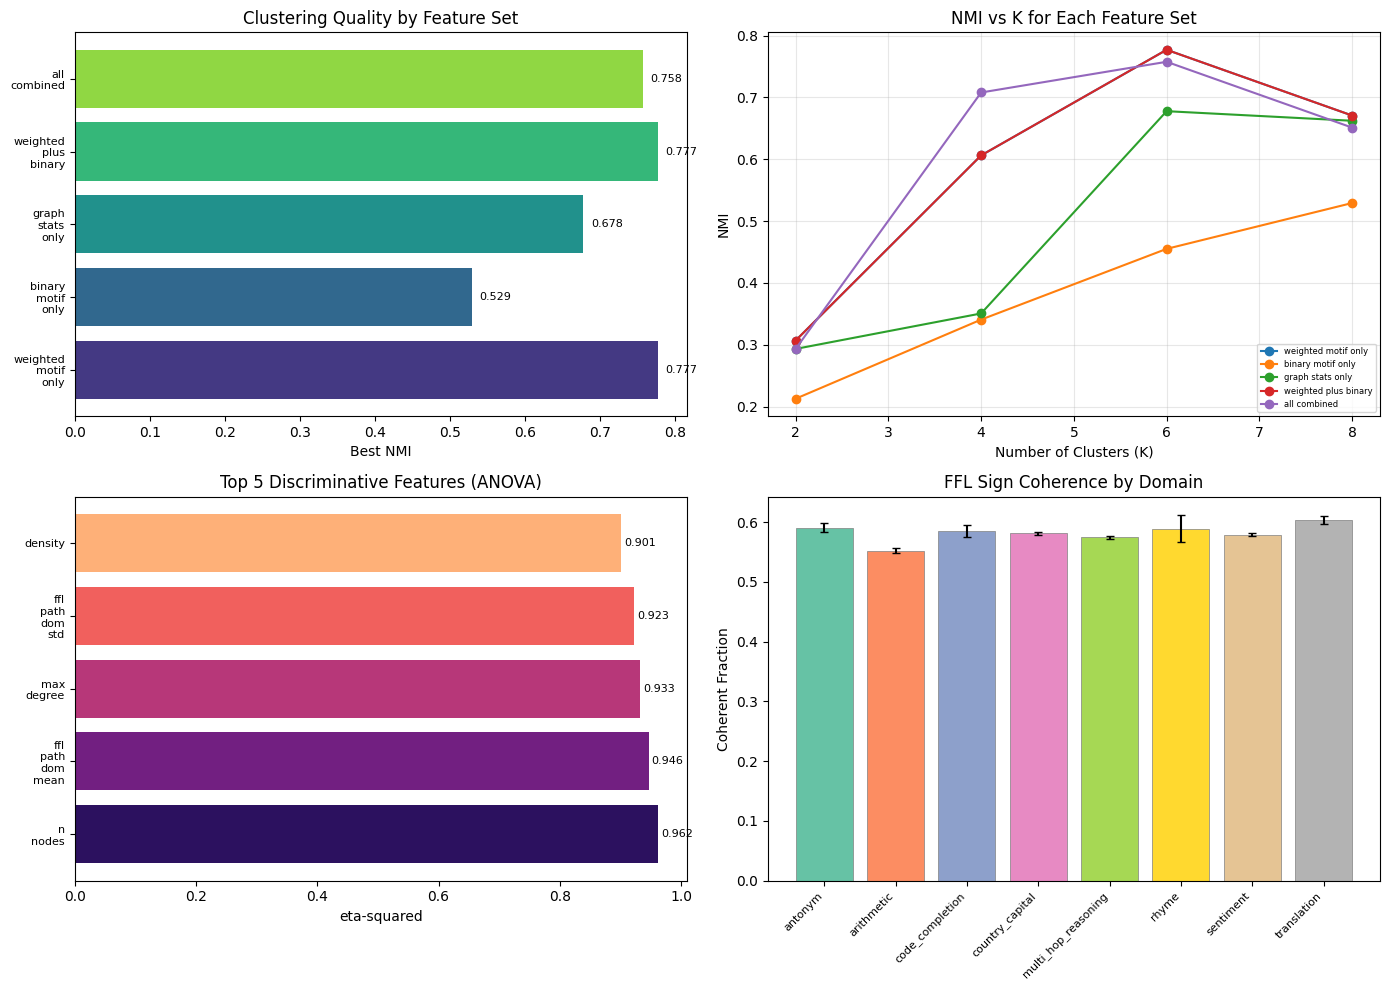

Figure saved to results_summary.png


In [12]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# --- Panel 1: Best NMI per feature set ---
ax = axes[0, 0]
fs_names = list(clustering_results.keys())
best_nmis = [clustering_results[fs]["best_nmi"] for fs in fs_names]
colors = sns.color_palette("viridis", len(fs_names))
bars = ax.barh(range(len(fs_names)), best_nmis, color=colors)
ax.set_yticks(range(len(fs_names)))
ax.set_yticklabels([n.replace("_", "\n") for n in fs_names], fontsize=8)
ax.set_xlabel("Best NMI")
ax.set_title("Clustering Quality by Feature Set")
for i, v in enumerate(best_nmis):
    ax.text(v + 0.01, i, f"{v:.3f}", va="center", fontsize=8)

# --- Panel 2: NMI across K values for each feature set ---
ax = axes[0, 1]
for fs_name in fs_names:
    ks = sorted(clustering_results[fs_name]["results_by_k"].keys(), key=int)
    nmis = [clustering_results[fs_name]["results_by_k"][k]["nmi"] for k in ks]
    ax.plot([int(k) for k in ks], nmis, marker="o", label=fs_name.replace("_", " "), linewidth=1.5)
ax.set_xlabel("Number of Clusters (K)")
ax.set_ylabel("NMI")
ax.set_title("NMI vs K for Each Feature Set")
ax.legend(fontsize=6, loc="lower right")
ax.grid(True, alpha=0.3)

# --- Panel 3: Top discriminative features (eta-squared) ---
ax = axes[1, 0]
if disc_results["top_5"]:
    top_names = list(disc_results["top_5"].keys())
    top_etas = [disc_results["top_5"][n]["eta_squared"] for n in top_names]
    ax.barh(range(len(top_names)), top_etas, color=sns.color_palette("magma", len(top_names)))
    ax.set_yticks(range(len(top_names)))
    ax.set_yticklabels([n.replace("_", "\n") for n in top_names], fontsize=8)
    ax.set_xlabel("eta-squared")
    ax.set_title("Top 5 Discriminative Features (ANOVA)")
    for i, v in enumerate(top_etas):
        ax.text(v + 0.005, i, f"{v:.3f}", va="center", fontsize=8)

# --- Panel 4: Sign coherence by domain ---
ax = axes[1, 1]
if sign_coh:
    dom_names = sorted(sign_coh.keys())
    coh_means = [sign_coh[d]["coherent_frac_mean"] for d in dom_names]
    coh_stds = [sign_coh[d]["coherent_frac_std"] for d in dom_names]
    x_pos = range(len(dom_names))
    ax.bar(x_pos, coh_means, yerr=coh_stds, color=sns.color_palette("Set2", len(dom_names)),
           capsize=3, edgecolor="gray", linewidth=0.5)
    ax.set_xticks(x_pos)
    ax.set_xticklabels(dom_names, rotation=45, ha="right", fontsize=8)
    ax.set_ylabel("Coherent Fraction")
    ax.set_title("FFL Sign Coherence by Domain")

plt.tight_layout()
plt.savefig("results_summary.png", dpi=100, bbox_inches="tight")
plt.show()
print("Figure saved to results_summary.png")

## Summary Table

In [13]:
# Print summary table
print("=" * 70)
print("CLUSTERING COMPARISON SUMMARY")
print("=" * 70)
print(f"{'Feature Set':<28} {'#Feat':>5} {'Best K':>6} {'NMI':>8} {'ARI':>8}")
print("-" * 70)
for fs_name, res in clustering_results.items():
    print(f"{fs_name:<28} {res.get('n_features', '?'):>5} {res['best_k']:>6} "
          f"{res['best_nmi']:>8.4f} {res['best_ari']:>8.4f}")
print("-" * 70)

print("\nPERMUTATION TEST RESULTS")
print("-" * 70)
print(f"{'Comparison':<40} {'Diff':>8} {'p-value':>10}")
print("-" * 70)
for comp_name, res in perm_results.items():
    sig = "***" if res["p_value"] < 0.001 else "**" if res["p_value"] < 0.01 else "*" if res["p_value"] < 0.05 else ""
    print(f"{comp_name:<40} {res['observed_diff']:>8.4f} {res['p_value']:>9.4f} {sig}")
print("-" * 70)

# Reference: full-scale results from the original paper
print("\nREFERENCE (full 200-graph run):")
ref = data["metadata"]["clustering_comparison"]
for fs_name, res in ref.items():
    print(f"  {fs_name}: NMI={res['best_nmi']:.4f} (K={res['best_k']})")

CLUSTERING COMPARISON SUMMARY
Feature Set                  #Feat Best K      NMI      ARI
----------------------------------------------------------------------
weighted_motif_only             19      6   0.7771   0.4697
binary_motif_only                4      8   0.5293   0.0424
graph_stats_only                 8      6   0.6778   0.2494
weighted_plus_binary            23      6   0.7771   0.4697
all_combined                    31      6   0.7577   0.4170
----------------------------------------------------------------------

PERMUTATION TEST RESULTS
----------------------------------------------------------------------
Comparison                                   Diff    p-value
----------------------------------------------------------------------
weighted_vs_binary                         0.3220    0.0196 *
weighted_vs_graph_stats                    0.0993    0.1373 
combined_vs_best_single                   -0.0194    0.6667 
weighted_plus_binary_vs_binary             0.3220    0.